In [1]:
# @title 1. Install Dependencies & Setup
!pip install torch_geometric sentence-transformers neo4j pandas scikit-learn wandb matplotlib seaborn -q

import os
import random
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import wandb
import time
from neo4j import GraphDatabase
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sentence_transformers import SentenceTransformer
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Ready. Using {device}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.4/325.4 kB 27.3 MB/s eta 0:00:00
Ready. Using cuda


In [2]:
# @title 2. Credentials & Login

# --- LOG IN TO WANDB ---
wandb.login()

# --- NEO4J CONFIG ---
URI = "neo4j+s://ccf24920.databases.neo4j.io"
AUTH = ("neo4j", "YHXssrChTu3r3FinSLYiNVUBhXoUEjcUDM-h0ERxD1E")

driver = GraphDatabase.driver(URI, auth=AUTH)
print("Driver Connected.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Find your API key here: https://wandb.ai/authorize
wandb: Paste an API key from your profile and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: nishanttg (nishantg) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Driver Connected.


In [3]:
# @title 3. Standardized Data Loader (Sorted Nodes + Rich Edges)

def load_standardized_data():
    with driver.session() as session:
        # A. Fetch Nodes (ORDER BY ID is CRITICAL for consistent splits)
        print(" Fetching Nodes (Sorted by ID)...")
        node_query = """
        MATCH (a:Article)
        OPTIONAL MATCH (p:Part)-[:HAS_ARTICLE]->(a)
        OPTIONAL MATCH (a)-[:GOVERNS]->(i:Institution)
        OPTIONAL MATCH (a)-[:TAGGED]->(t:Tag)
        RETURN
            a.id as id,
            a.text as text,
            a.title as title,
            labels(a) as neo_labels,
            collect(distinct i.name) as institutions,
            collect(distinct t.name) as tags
        ORDER BY a.id ASC
        """
        df_nodes = pd.DataFrame([r.data() for r in session.run(node_query)])

        # B. Fetch Edges (Citations + Structure)
        print("Fetching Edges (Reference + Structure)...")
        edge_query = """
        // 1. Citations
        MATCH (s:Article)-[:REFERENCES]->(t:Article) RETURN s.id as source, t.id as target
        UNION
        // 2. Structural Neighbors (Same Part)
        MATCH (s:Article)<-[:HAS_ARTICLE]-(p:Part)-[:HAS_ARTICLE]->(t:Article)
        WHERE s.id < t.id
        RETURN s.id as source, t.id as target
        """
        df_edges = pd.DataFrame([r.data() for r in session.run(edge_query)])

    # --- ADVANCED LABELING ---
    labels = []
    class_names = ["Rights", "Judiciary", "Federalism", "Governance", "Other"]

    for _, row in df_nodes.iterrows():
        text = (str(row['text']) + " " + str(row.get('title', ''))).lower()
        neo = row['neo_labels']; insts = row['institutions']; tags = row['tags']

        if "FundamentalRight" in neo or any(t in tags for t in ["Women", "Dalit"]): labels.append(0)
        elif any(i in insts for i in ["Supreme Court", "High Court"]): labels.append(1)
        elif any(k in text for k in ["province", "federation"]): labels.append(2)
        elif any(k in text for k in ["president", "parliament", "minister"]): labels.append(3)
        elif "right" in text and "freedom" in text: labels.append(0)
        elif "court" in text: labels.append(1)
        else: labels.append(4)

    # --- FEATURES (SBERT) ---
    print(" Generating SBERT Features...")
    embedder = SentenceTransformer('all-MiniLM-L6-v2')
    x = torch.tensor(embedder.encode(df_nodes['text'].tolist()), dtype=torch.float)
    y = torch.tensor(labels, dtype=torch.long)

    # --- GRAPH TOPOLOGY ---
    id_map = {id: i for i, id in enumerate(df_nodes['id'])}
    src = [id_map[x] for x in df_edges['source'] if x in id_map]
    dst = [id_map[x] for x in df_edges['target'] if x in id_map]
    edge_index = torch.tensor([src + dst, dst + src], dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)

    # --- DETERMINISTIC SPLIT ---
    indices = np.arange(data.num_nodes)
    train_idx, test_idx = train_test_split(indices, test_size=0.25, stratify=data.y.numpy(), random_state=SEED)

    data.train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.test_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
    data.train_mask[train_idx] = True
    data.test_mask[test_idx] = True

    print(f"Data Ready. Total Nodes: {data.num_nodes}")
    print(f"Test Set Size: {len(test_idx)}")

    return data.to(device), class_names

# Load Data
data, class_names = load_standardized_data()

 Fetching Nodes (Sorted by ID)...
Fetching Edges (Reference + Structure)...
 Generating SBERT Features...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Data Ready. Total Nodes: 308
Test Set Size: 77


In [4]:
  # @title 4. Define GraphSAGE Model

class GraphSAGE(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # SAGEConv (Mean Aggregation is standard)
        self.conv1 = SAGEConv(data.num_features, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 5) # 5 Classes

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.5, training=self.training)
        x = self.conv2(x, edge_index)
        return x

# Initialize
model = GraphSAGE(hidden_channels=128).to(device) # Increased hidden dim for SAGE
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Calculate Class Weights (for Imbalance)
class_counts = torch.bincount(data.y)
weights = 1. / class_counts.float()
weights = weights / weights.sum()
criterion = torch.nn.CrossEntropyLoss(weight=weights)

print(model)

GraphSAGE(
  (conv1): SAGEConv(384, 128, aggr=mean)
  (conv2): SAGEConv(128, 5, aggr=mean)
)


Training GraphSAGE...
 Inference Time: 29.53 ms

Macro F1: 0.8349

 Report:
              precision    recall  f1-score   support

      Rights       1.00      0.85      0.92        20
   Judiciary       1.00      0.75      0.86         8
  Federalism       0.67      0.67      0.67         3
  Governance       0.80      0.94      0.86        17
       Other       0.84      0.90      0.87        29

    accuracy                           0.87        77
   macro avg       0.86      0.82      0.83        77
weighted avg       0.88      0.87      0.87        77



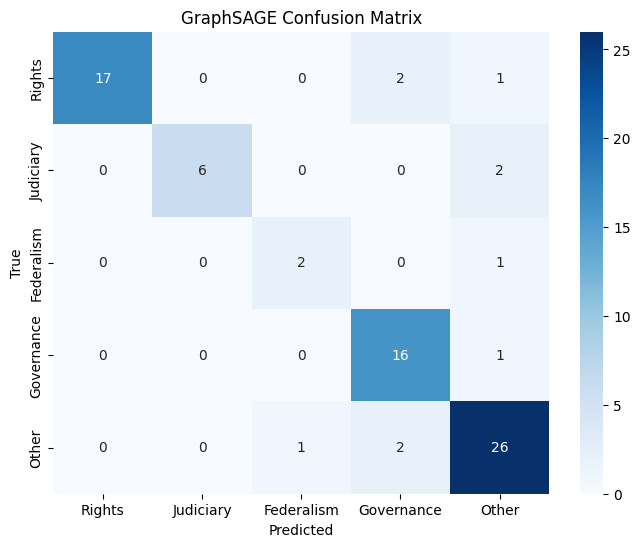

inference_time_ms,▁
test_macro_f1,▁
train_loss,█▂▁▁▁▁▁▁▁▁
inference_time_ms,29.52909
test_macro_f1,0.83485
train_loss,0.0302


In [5]:
# @title 5. Train & Evaluate GraphSAGE

def train_and_log_sage():
    run = wandb.init(
        project="Week-5",
        name="Day-4-GraphSage",
        config={"model": "GraphSAGE", "hidden_dim": 128, "lr": 0.01}
    )

    # --- TRAINING ---
    print("Training GraphSAGE...")
    model.train()
    for epoch in range(200):
        optimizer.zero_grad()
        out = model(data.x, data.edge_index)
        loss = criterion(out[data.train_mask], data.y[data.train_mask])
        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            wandb.log({"train_loss": loss.item()})

    # --- INFERENCE COST ---
    model.eval()
    start_time = time.time()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out.argmax(dim=1)
        probas = F.softmax(out, dim=1)
    end_time = time.time()

    inf_time = (end_time - start_time) * 1000 # ms
    print(f" Inference Time: {inf_time:.2f} ms")

    # --- METRICS ---
    y_true = data.y[data.test_mask].cpu().numpy()
    y_pred = pred[data.test_mask].cpu().numpy()
    y_score = probas[data.test_mask].cpu().numpy()

    macro_f1 = f1_score(y_true, y_pred, average='macro')

    print(f"\nMacro F1: {macro_f1:.4f}")

    # 1. Classification Report
    report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True, zero_division=0)
    print("\n Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    wandb.log({"classification_report": wandb.Table(dataframe=pd.DataFrame(report_dict).T)})

    # 2. Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title('GraphSAGE Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.savefig("cm_sage.png", bbox_inches='tight', dpi=120)
    wandb.log({"confusion_matrix": wandb.Image("cm_sage.png")})
    plt.show()
    plt.close()

    # 3. ROC Curves
    wandb.sklearn.plot_roc(y_true, y_score, labels=class_names)

    # Log Summary Stats
    wandb.log({
        "test_macro_f1": macro_f1,
        "inference_time_ms": inf_time
    })

    run.finish()

train_and_log_sage()